## Obective: 
### X, and y variables data preparation are ready. 

- X: 74 quarterly data with aggregation rules (Economic Consumptions sector)
- y: Real_PCE Growth rate QoQ 

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [30]:
DATA_DIR = Path("data")
X= pd.read_csv(DATA_DIR / "Consumption_Model_PreSplit_X.csv")
print(X.shape)
print(X.head(2))

(77, 74)
      Quarter  Disposable Personal Income  Personal Income  \
0  2007-06-30                   10267.697     11734.233333   
1  2007-09-30                   10406.081     11902.000000   

   Real Disposable Income  Average Hourly Earnings  Weekly Earnings  \
0            11995.900000                20.663333            336.0   
1            12055.333333                20.860000            335.0   

   Wage Growth  Labor Compensation  Self-employment Income  Rental Income  \
0     4.266667              79.884                1017.222        162.476   
1     4.033333              79.829                 998.504        180.253   

   ...  Market Volatility (VIX)     Population  Working-age Population  \
0  ...                12.563607  300609.666667           230839.333333   
1  ...                13.731905  301283.666667           231482.000000   

   Single-Family Housing Starts  Vehicle Sales  Tax Refunds  \
0                   1173.666667      16.834333     1606.513   
1        

In [31]:
DATA_DIR = Path("data")
y_train= pd.read_csv(DATA_DIR / "PCE_Classification_Train.csv")
print(y_train.shape)
print(y_train.head(2))

(59, 4)
         DATE  Real_PCE  Real_PCE_Growth_QoQ  PCE_Regime
0  2007-06-30   11218.5             0.248421           0
1  2007-09-30   11309.6             0.812052           1


In [32]:
DATA_DIR = Path("data")
y= pd.read_csv(DATA_DIR / "Consumption_Model_PreSplit_y.csv")
print(y.shape)
print(y.head(2))

(77, 2)
      Quarter    target
0  2007-06-30  0.262594
1  2007-09-30  0.666805


## Convert the numerical target to Class 0/ Class 1

### After analysis, we have define the binary classification threshold is Median (Y-train) = 0.5576 as PCE growth target binary classes

In [33]:
# ============================================================
# Convert continuous PCE growth target to binary classes
# ============================================================

threshold = 0.5576

y["PCE_Regime"]= (y["target"]> threshold). astype(int)

print("Classification threshold:", threshold)
print(y.shape)
display(y.head(2))

Classification threshold: 0.5576
(77, 3)


,Quarter,target,PCE_Regime
0,2007-06-30,0.262594,0
1,2007-09-30,0.666805,1


In [34]:
y["Regime_Label"] = y["PCE_Regime"].map({
    0: "Weak Growth",
    1: "Strong Growth"
})

display(y.head(10))

,Quarter,target,PCE_Regime,Regime_Label
0,2007-06-30,0.262594,0,Weak Growth
1,2007-09-30,0.666805,1,Strong Growth
2,2007-12-31,0.394539,0,Weak Growth
3,2008-03-31,-0.137370,0,Weak Growth
4,2008-06-30,0.275706,0,Weak Growth
5,2008-09-30,-0.770794,0,Weak Growth
6,2008-12-31,-0.899634,0,Weak Growth
7,2009-03-31,-0.254208,0,Weak Growth
8,2009-06-30,-0.491743,0,Weak Growth
9,2009-09-30,0.672642,1,Strong Growth


In [35]:
X_model = X.copy()

# Convert Quarter to datetime
X_model["Quarter"] = pd.to_datetime(
    X_model["Quarter"]
)

# Set Quarter as index
X_model = X_model.set_index("Quarter")

# Sort chronologically
X_model = X_model.sort_index()

print(type(X_model.index))
print(X_model.index[:5])
display(X_model.head(2))

<class 'pandas.DatetimeIndex'>
DatetimeIndex(['2007-06-30', '2007-09-30', '2007-12-31', '2008-03-31',
               '2008-06-30'],
              dtype='datetime64[us]', name='Quarter', freq=None)


,Disposable Personal Income,Personal Income,Real Disposable Income,Average Hourly Earnings,Weekly Earnings,Wage Growth,Labor Compensation,Self-employment Income,Rental Income,Dividend Income,...,Market Volatility (VIX),Population,Working-age Population,Single-Family Housing Starts,Vehicle Sales,Tax Refunds,Unemployment Benefits,Oil Price,Gasoline Price,Exchange Rate
Quarter,,,,,,,,,,,,,,,,,,,,,
2007-06-30,10267.697,11734.233333,11995.900000,20.663333,336.0,4.266667,79.884,1017.222,162.476,739.633333,...,12.563607,300609.666667,230839.333333,1173.666667,16.834333,1606.513,32.266667,58.075000,2.350846,97.439534
2007-09-30,10406.081,11902.000000,12055.333333,20.860000,335.0,4.033333,79.829,998.504,180.253,784.100000,...,13.731905,301283.666667,231482.000000,1152.666667,16.485000,1619.091,31.833333,64.965238,3.002538,94.926737


In [36]:
y_class= y[["Quarter","PCE_Regime"]]
y_class.head(2)

,Quarter,PCE_Regime
0,2007-06-30,0
1,2007-09-30,1


In [37]:
y_model = y_class.copy()

y_model["Quarter"] = pd.to_datetime(
    y_model["Quarter"]
)

y_model = y_model.set_index("Quarter")

# Keep only the classification target
y_model = y_model["PCE_Regime"]

y_model = y_model.sort_index()

print(type(y_model.index))
print(y_model.index[:5])

display(y_model.head())

<class 'pandas.DatetimeIndex'>
DatetimeIndex(['2007-06-30', '2007-09-30', '2007-12-31', '2008-03-31',
               '2008-06-30'],
              dtype='datetime64[us]', name='Quarter', freq=None)


Quarter
2007-06-30    0
2007-09-30    1
2007-12-31    0
2008-03-31    0
2008-06-30    0
Name: PCE_Regime, dtype: int64

In [38]:
# ============================================================
# LOGISTIC REGRESSION MODEL
# PCE Growth Regime Classification
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

## 1. Prepare X and y

- X = economic predictor dataframe
- y_class = dataframe containing Quarter and PCE_Regime
- 0 = Weak PCE Growth
- 1 = Strong PCE Growth

In [39]:
# ============================================================
# 1. VERIFY X AND y
# ============================================================

print("X_model shape:", X_model.shape)
print("y_model shape:", y_model.shape)

print("\nX index type:")
print(type(X_model.index))

print("\ny index type:")
print(type(y_model.index))

print("\nSame dates?")
print(X_model.index.equals(y_model.index))

print("\nX date range:")
print(X_model.index.min(), "to", X_model.index.max())

print("\ny date range:")
print(y_model.index.min(), "to", y_model.index.max())

X_model shape: (77, 73)
y_model shape: (77,)

X index type:
<class 'pandas.DatetimeIndex'>

y index type:
<class 'pandas.DatetimeIndex'>

Same dates?
True

X date range:
2007-06-30 00:00:00 to 2026-06-30 00:00:00

y date range:
2007-06-30 00:00:00 to 2026-06-30 00:00:00


## 2. Chronological train/test split

In [40]:
# ============================================================
# 2. CHRONOLOGICAL TRAIN / TEST SPLIT
# ============================================================

split_date = pd.Timestamp("2022-01-01")

X_train = X_model.loc[X_model.index < split_date].copy()
X_test  = X_model.loc[X_model.index >= split_date].copy()

y_train = y_model.loc[y_model.index < split_date].copy()
y_test  = y_model.loc[y_model.index >= split_date].copy()


print("=" * 50)
print("TRAIN / TEST SPLIT")
print("=" * 50)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining period:")
print(X_train.index.min(), "to", X_train.index.max())

print("\nTesting period:")
print(X_test.index.min(), "to", X_test.index.max())

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

TRAIN / TEST SPLIT
Training observations: 59
Testing observations: 18

Training period:
2007-06-30 00:00:00 to 2021-12-31 00:00:00

Testing period:
2022-03-31 00:00:00 to 2026-06-30 00:00:00

Training class distribution:
PCE_Regime
0    29
1    30
Name: count, dtype: int64

Testing class distribution:
PCE_Regime
0     8
1    10
Name: count, dtype: int64


## 3. Check missing values

In [41]:
# ============================================================
# 3. CHECK MISSING VALUES
# ============================================================

missing_train = X_train.isna().sum()

print("Features with missing values in training data:")
display(
    missing_train[missing_train > 0]
    .sort_values(ascending=False)
)

print("\nTotal missing values in training data:")
print(X_train.isna().sum().sum())

print("\nTotal missing values in testing data:")
print(X_test.isna().sum().sum())

Features with missing values in training data:


Series([], dtype: int64)


Total missing values in training data:
0

Total missing values in testing data:
0


### Saving `X_train`, `y_train`, `X_test`, and `y_test` as CSV files

In [42]:
# Define the data folder
DATA_DIR = Path("data")

# Create the folder if it does not already exist
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Save datasets
X_train.to_csv(DATA_DIR / "(experiment) X_train.csv", index=True)
y_train.to_csv(DATA_DIR / "(experiment) y_train.csv", index=True)

X_test.to_csv(DATA_DIR / "(experiment) X_test.csv", index=True)
y_test.to_csv(DATA_DIR / "(experiment) y_test.csv", index=True)

print("Files saved successfully:")
print(DATA_DIR / "(experiment) X_train.csv")
print(DATA_DIR / "(experiment) y_train.csv")
print(DATA_DIR / "(experiment) X_test.csv")
print(DATA_DIR / "(experiment) y_test.csv")


Files saved successfully:
data/(experiment) X_train.csv
data/(experiment) y_train.csv
data/(experiment) X_test.csv
data/(experiment) y_test.csv


## 4. Correlation wiht PCE Regime

In [43]:
# ============================================================
# 4. CORRELATION WITH PCE REGIME
# Training data only
# ============================================================

corr_data = X_train.copy()

corr_data["PCE_Regime"] = y_train

# Calculate correlations
corr_matrix = corr_data.corr(numeric_only=True)

target_corr = (
    corr_matrix["PCE_Regime"]
    .drop("PCE_Regime")
    .sort_values(
        key=abs,
        ascending=False
    )
)

print("=" * 60)
print("TOP CORRELATIONS WITH PCE REGIME")
print("=" * 60)

display(target_corr.head(15))

TOP CORRELATIONS WITH PCE REGIME


Labor Force Participation Rate   -0.374664
Transfer Payments                 0.359243
Mortgage Rate                    -0.359024
Personal Loan Rate               -0.352889
Corporate Bond Yield             -0.341359
Employment Rate                  -0.332021
Food Inflation                    0.331885
Financial Assets                  0.330330
Social Security Benefits          0.326661
Labor Compensation                0.326115
Average Hourly Earnings           0.325152
Personal Savings                  0.319895
Household Net Worth               0.319002
Real Disposable Income            0.317942
Savings Rate                      0.316756
Name: PCE_Regime, dtype: float64

`Interpretation:`

## 5. Correlation Heatmap 

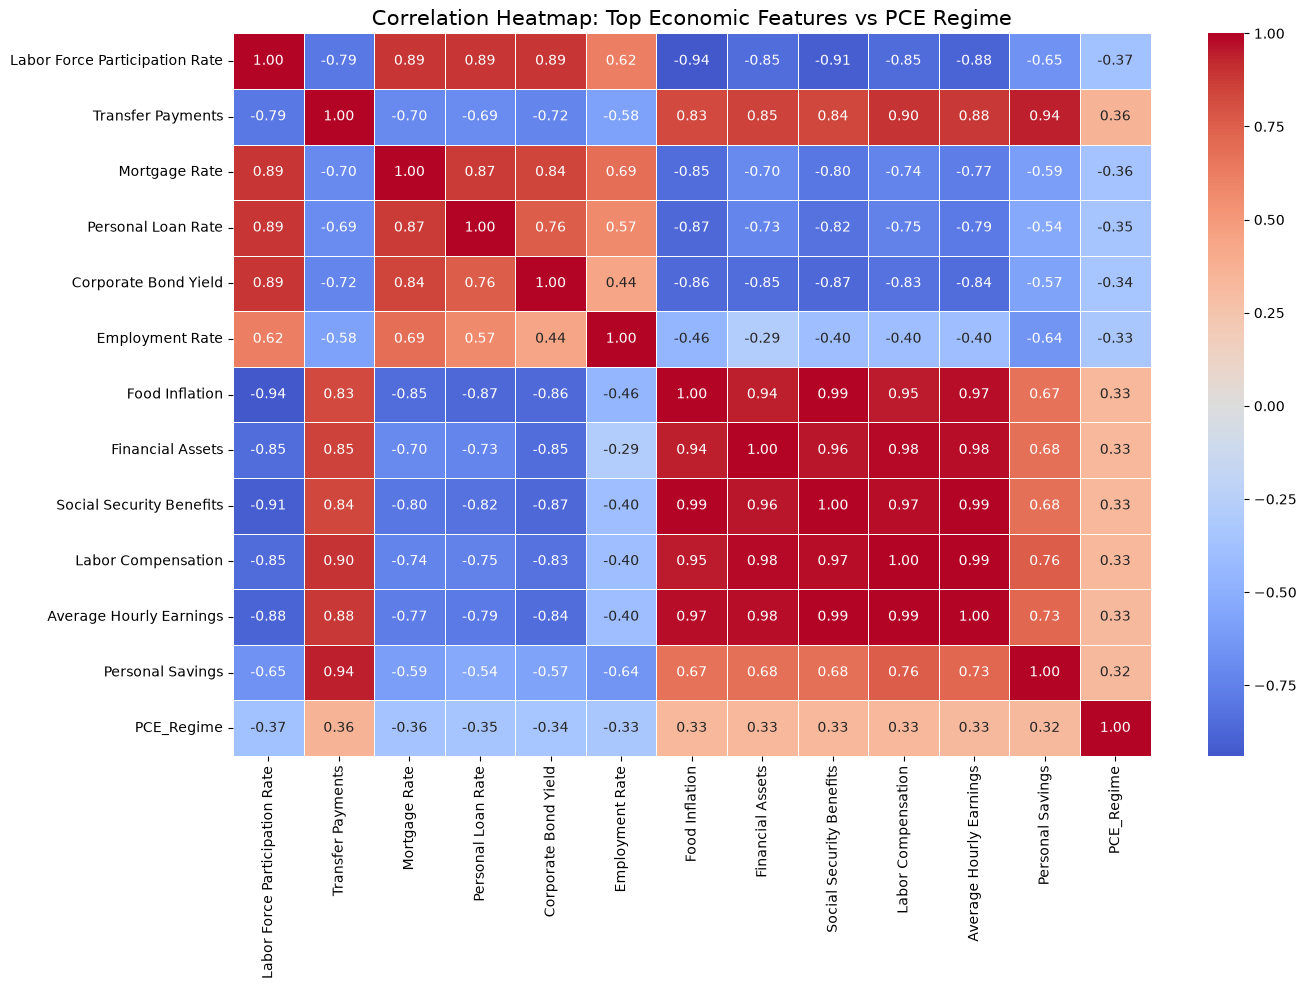

In [44]:
# ============================================================
# 5. CORRELATION HEATMAP
# ============================================================

top_n = 12

top_features = (
    target_corr
    .abs()
    .head(top_n)
    .index
    .tolist()
)

heatmap_features = top_features + ["PCE_Regime"]


plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_data[heatmap_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Correlation Heatmap: Top Economic Features vs PCE Regime",
    fontsize=15
)

plt.tight_layout()
plt.show()

## 6. Build Logistic Regression Pipeline

In [45]:
# ============================================================
# 6. LOGISTIC REGRESSION PIPELINE
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


logistic_pipeline = Pipeline([
    
    # Handle missing values using TRAINING medians
    ("imputer", SimpleImputer(strategy="median")),
    
    # Standardize predictors
    ("scaler", StandardScaler()),
    
    # Logistic Regression classifier
    ("logistic", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
    
])

## 7. Train the Model

In [46]:
# ============================================================
# 7. TRAIN LOGISTIC REGRESSION
# ============================================================

logistic_pipeline.fit(
    X_train,
    y_train
)

print("Logistic Regression training completed.")

Logistic Regression training completed.


## 8. Generate Predictions

In [47]:
# ============================================================
# 8. GENERATE TEST PREDICTIONS
# ============================================================

y_pred = logistic_pipeline.predict(X_test)

y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]


prediction_results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Probability_Strong": y_prob
})

display(prediction_results)

,Actual,Predicted,Probability_Strong
Quarter,,,
2022-03-31,0,1,0.877807
2022-06-30,1,0,0.379936
2022-09-30,0,0,0.144948
2022-12-31,0,0,0.141741
2023-03-31,1,0,0.128178
2023-06-30,0,0,0.285749
2023-09-30,1,0,0.355091
2023-12-31,1,1,0.549757
2024-03-31,0,0,0.364214


## 9. Calculate Performance Metrics

In [48]:
# ============================================================
# 9. PERFORMANCE METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


print("=" * 55)
print("LOGISTIC REGRESSION MODEL PERFORMANCE")
print("=" * 55)

print(f"Accuracy:           {accuracy:.4f}")
print(f"Balanced Accuracy:  {balanced_accuracy:.4f}")
print(f"Precision:          {precision:.4f}")
print(f"Recall:             {recall:.4f}")
print(f"F1 Score:           {f1:.4f}")
print(f"ROC-AUC:            {roc_auc:.4f}")

LOGISTIC REGRESSION MODEL PERFORMANCE
Accuracy:           0.5556
Balanced Accuracy:  0.5750
Precision:          0.6667
Recall:             0.4000
F1 Score:           0.5000
ROC-AUC:            0.5500


## 10. Classification Report 

In [49]:
# ============================================================
# 10. CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Weak Growth",
            "Strong Growth"
        ],
        zero_division=0
    )
)

               precision    recall  f1-score   support

  Weak Growth       0.50      0.75      0.60         8
Strong Growth       0.67      0.40      0.50        10

     accuracy                           0.56        18
    macro avg       0.58      0.57      0.55        18
 weighted avg       0.59      0.56      0.54        18



## 11. Confusion Matrix

In [50]:
# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[6 2]
 [6 4]]


$$
\begin{bmatrix}
TN=6 & FP=2 \\
FN=6 & TP=4
\end{bmatrix}
$$

TN = Weak Growth correctly predicted as Weak\
FP = Weak Growth incorrectly predicted as Strong

FN = Strong Growth incorrectly predicted as Weak\
TP = Strong Growth correctly predicted as Strong

## 12. Visualize the Confusion Matrix

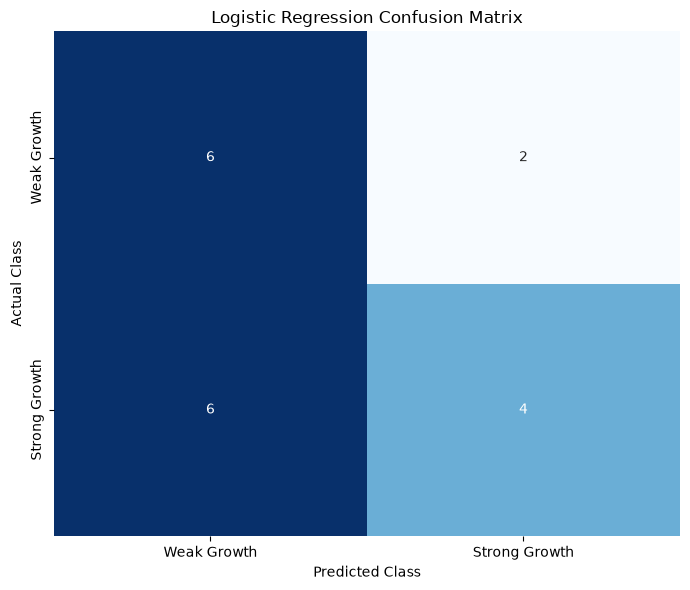

In [51]:
# ============================================================
# CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=[
        "Weak Growth",
        "Strong Growth"
    ],
    yticklabels=[
        "Weak Growth",
        "Strong Growth"
    ]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.tight_layout()
plt.show()

## 13. Performance Summary Table

In [52]:
# ============================================================
# 13. MODEL PERFORMANCE SUMMARY
# ============================================================

logistic_results = pd.DataFrame({

    "Model": [
        "Logistic Regression"
    ],

    "Accuracy": [
        accuracy
    ],

    "Balanced Accuracy": [
        balanced_accuracy
    ],

    "Precision": [
        precision
    ],

    "Recall": [
        recall
    ],

    "F1": [
        f1
    ],

    "ROC-AUC": [
        roc_auc
    ]
})


display(
    logistic_results.round(4)
)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.5556,0.575,0.6667,0.4,0.5,0.55


## 14. Logistic Regression Coefficients for Economic Feature Discovery

In [53]:
# ============================================================
# 14. LOGISTIC REGRESSION COEFFICIENTS
# ============================================================

logistic_model = logistic_pipeline.named_steps["logistic"]

coefficients = logistic_model.coef_[0]


coef_df = pd.DataFrame({

    "Feature": X_train.columns,

    "Coefficient": coefficients

})


coef_df["Absolute_Coefficient"] = (
    coef_df["Coefficient"].abs()
)


coef_df = coef_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
)


display(coef_df.head(20))

,Feature,Coefficient,Absolute_Coefficient
35,Savings Rate,0.762509,0.762509
28,Economic Policy Uncertainty,-0.730121,0.730121
9,Dividend Income,0.615563,0.615563
27,Inflation Expectations,-0.597637,0.597637
36,Personal Savings,0.532955,0.532955
19,Full-time Employment,-0.470965,0.470965
68,Tax Refunds,0.449137,0.449137
67,Vehicle Sales,-0.438717,0.438717
55,Transportation Inflation,-0.406329,0.406329
43,Personal Loan Rate,-0.393697,0.393697


In [54]:
# ============================================================
# POSITIVE COEFFICIENTS
# Higher values → stronger association with Class 1
# ============================================================

positive_coef = (
    coef_df[coef_df["Coefficient"] > 0]
    .sort_values(
        "Coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

# ============================================================
# NEGATIVE COEFFICIENTS
# Higher values → stronger association with Class 0
# ============================================================

negative_coef = (
    coef_df[coef_df["Coefficient"] < 0]
    .sort_values(
        "Coefficient",
        ascending=True
    )
    .reset_index(drop=True)
)

In [55]:
print("TOP 10 POSITIVE COEFFICIENTS")
display(positive_coef.head(10))

print("\nTOP 10 NEGATIVE COEFFICIENTS")
display(negative_coef.head(10))

TOP 10 POSITIVE COEFFICIENTS


,Feature,Coefficient,Absolute_Coefficient
0,Savings Rate,0.762509,0.762509
1,Dividend Income,0.615563,0.615563
2,Personal Savings,0.532955,0.532955
3,Tax Refunds,0.449137,0.449137
4,Treasury Yield,0.335009,0.335009
5,Auto Loan Rate,0.325483,0.325483
6,Quit Rate,0.262569,0.262569
7,Delinquency Rate,0.257721,0.257721
8,Continuing Claims,0.240844,0.240844
9,Hiring Rate,0.232607,0.232607



TOP 10 NEGATIVE COEFFICIENTS


,Feature,Coefficient,Absolute_Coefficient
0,Economic Policy Uncertainty,-0.730121,0.730121
1,Inflation Expectations,-0.597637,0.597637
2,Full-time Employment,-0.470965,0.470965
3,Vehicle Sales,-0.438717,0.438717
4,Transportation Inflation,-0.406329,0.406329
5,Personal Loan Rate,-0.393697,0.393697
6,Layoff Rate,-0.378178,0.378178
7,Weekly Earnings,-0.373120,0.373120
8,Payroll Employment,-0.326902,0.326902
9,Corporate Bond Yield,-0.312385,0.312385


In [56]:
# ============================================================
# DISPLAY RESULTS
# ============================================================

print("=" * 60)
print("POSITIVE COEFFICIENTS")
print("Associated with higher predicted probability of Strong Growth")
print("=" * 60)

display(positive_coef)


print("\n" + "=" * 60)
print("NEGATIVE COEFFICIENTS")
print("Associated with lower predicted probability of Strong Growth")
print("=" * 60)

display(negative_coef)

POSITIVE COEFFICIENTS
Associated with higher predicted probability of Strong Growth


,Feature,Coefficient,Absolute_Coefficient
0,Savings Rate,0.762509,0.762509
1,Dividend Income,0.615563,0.615563
2,Personal Savings,0.532955,0.532955
3,Tax Refunds,0.449137,0.449137
4,Treasury Yield,0.335009,0.335009
5,Auto Loan Rate,0.325483,0.325483
6,Quit Rate,0.262569,0.262569
7,Delinquency Rate,0.257721,0.257721
8,Continuing Claims,0.240844,0.240844
9,Hiring Rate,0.232607,0.232607



NEGATIVE COEFFICIENTS
Associated with lower predicted probability of Strong Growth


,Feature,Coefficient,Absolute_Coefficient
0,Economic Policy Uncertainty,-0.730121,0.730121
1,Inflation Expectations,-0.597637,0.597637
2,Full-time Employment,-0.470965,0.470965
3,Vehicle Sales,-0.438717,0.438717
4,Transportation Inflation,-0.406329,0.406329
5,Personal Loan Rate,-0.393697,0.393697
6,Layoff Rate,-0.378178,0.378178
7,Weekly Earnings,-0.373120,0.373120
8,Payroll Employment,-0.326902,0.326902
9,Corporate Bond Yield,-0.312385,0.312385


## 15. Visualize Top Logistic Regression Coefficients

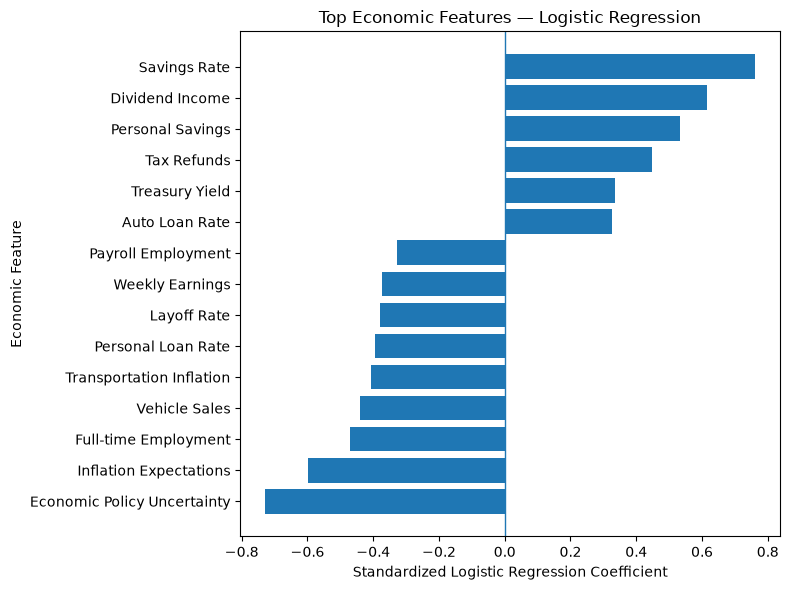

In [57]:
# ============================================================
# TOP 15 LOGISTIC REGRESSION COEFFICIENTS
# ============================================================

top_coef = (
    coef_df
    .head(15)
    .sort_values("Coefficient")
)


plt.figure(figsize=(8, 6))

plt.barh(
    top_coef["Feature"],
    top_coef["Coefficient"]
)

plt.axvline(
    x=0,
    linewidth=1
)

plt.xlabel(
    "Standardized Logistic Regression Coefficient"
)

plt.ylabel(
    "Economic Feature"
)

plt.title(
    "Top Economic Features — Logistic Regression"
)

plt.tight_layout()
plt.show()